# Difference in difference

We call 'Uncofoundedness' a scenario where a treatment is not randomly assigned to participants, so confounders effect on treatment assignment and outcome. We have client - level data. Confounders were measured before treatment and outcome after

In [1]:
from causalis.scenarios.did.dgp import generate_did_gamma_26

data = generate_did_gamma_26(return_panel_data=False, include_oracles=True)
data.head(100)


,unit_id,region,segment,is_treated_unit,cohort,calendar_time,event_time,observed,treated_time,y,y_cf,tau_realized_true,mu_cf,mu_treated,tau_mean_true,exposure,avg_order_value,market_competition,macro_index,seasonality_index
0,control_market_01,central,core,0,NaT,2021-01,<NA>,1,0,469.338527,469.338527,0.0,898.785094,898.785094,0.0,0.680902,47.316936,0.492092,1.003048,1.080000
1,control_market_01,central,core,0,NaT,2021-02,<NA>,1,0,1994.629695,1994.629695,0.0,1041.664684,1041.664684,0.0,0.730334,47.396458,0.439617,0.978026,1.120000
2,control_market_01,central,core,0,NaT,2021-03,<NA>,1,0,998.702702,998.702702,0.0,1091.327752,1091.327752,0.0,0.737621,46.329461,0.458586,1.013055,1.098564
3,control_market_01,central,core,0,NaT,2021-04,<NA>,1,0,894.775432,894.775432,0.0,1037.073027,1037.073027,0.0,0.666858,46.778886,0.447466,1.041784,1.080000
4,control_market_01,central,core,0,NaT,2021-05,<NA>,1,0,813.824651,813.824651,0.0,1281.774057,1281.774057,0.0,0.800159,48.705252,0.403332,1.025656,1.098564
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,control_market_03,central,core,0,NaT,2023-08,<NA>,1,0,1122.551240,1122.551240,0.0,1267.114519,1267.114519,0.0,0.998114,47.157164,0.403299,0.960864,0.960000
96,control_market_04,west,core,0,NaT,2021-01,<NA>,1,0,1889.010276,1889.010276,0.0,1902.934770,1902.934770,0.0,1.102109,48.782439,0.434794,1.003048,1.080000
97,control_market_04,west,core,0,NaT,2021-02,<NA>,1,0,1895.906012,1895.906012,0.0,2010.512365,2010.512365,0.0,1.042597,53.580988,0.459483,0.978026,1.120000
98,control_market_04,west,core,0,NaT,2021-03,<NA>,1,0,1842.505009,1842.505009,0.0,1994.338940,1994.338940,0.0,1.090320,51.840410,0.434064,1.013055,1.098564


In [2]:
data.groupby(['is_treated_unit', 'calendar_time'])['y'].sum()

is_treated_unit  calendar_time
0                2021-01          111361.364257
                 2021-02          134519.803467
                 2021-03          113694.756303
                 2021-04          114740.158294
                 2021-05          120531.965221
                                      ...      
1                2023-04           45478.239469
                 2023-05           46485.637847
                 2023-06           53933.427314
                 2023-07           45364.853988
                 2023-08           39330.677225
Name: y, Length: 64, dtype: float64

In [3]:
from causalis.data_contracts import PanelDataDID

panel_data = PanelDataDID(
    df=data,
    y="y",
    unit_col="unit_id",
    time_col="calendar_time",
    treated_time="treated_time",
    covariates=["exposure", "avg_order_value"],
    cluster_col="region",
)


## Pre-fit diagnostics for Callaway-SantAnna DID

Run these checks after `PanelDataDID(...)` and before `CallawaySantAnnaDID(...).fit(...)`. They use the same control-group, anticipation, and base-period choices that the model will use.

In [4]:
from causalis.scenarios.did import (
    CallawaySantAnnaDID,
    did_support_table,
    plot_did_support,
    plot_raw_did_event_study,
    raw_did_event_study_table,
    run_did_diagnostics,
)

cs_options = dict(
    control_group="not_yet_or_never",
    anticipation=0,
    base_period="universal",
    include_pre_periods=True,
)

diagnostics = run_did_diagnostics(
    panel_data,
    **cs_options,
    min_treated_per_cell=4,
    min_control_per_cell=10,
    max_abs_covariate_smd=1.0,
)

diagnostics


,test,flag,value,threshold,message
0,requested_cs_post_support,GREEN,18,>= 1,"At least one post-treatment ATT(g,t) cell is s..."
1,unsupported_post_cell_share,GREEN,0.0,<= 0.25,Unsupported post-treatment cell share is withi...
2,min_complete_treated_per_post_cell,GREEN,5,>= 4,Complete treated units per supported post cell...
3,min_complete_control_per_post_cell,GREEN,60,>= 10,Complete control units per supported post cell...
4,min_control_to_treated_ratio,GREEN,12.0,>= 1,Control-to-treated ratios are within tolerance...
5,min_pair_completion_rate,GREEN,1.0,>= 0.8,Complete-pair rates are within tolerance for s...
6,control_pool_retention,GREEN,0.8,>= 0.25,Comparison-pool retention is within tolerance ...
7,cluster_readiness,GREEN,"{'n_clusters': 5, 'unstable_units': 0}",stable within unit and clusters >= 2,cluster_col is stable within unit and has enou...
8,pre_period_depth,GREEN,24,>= 2,There are enough pre-periods for basic pre-tre...
9,raw_pretrend_placebo,YELLOW,3.067697,max |t| <= 2,Raw pre-treatment DID placebo cells show a lar...


In [5]:
support = did_support_table(panel_data, **cs_options)
support.head(12)


,support_cell_id,cohort,time,base_time,event_time,control_group,anticipation,base_period,is_post_treatment,n_treated_available,...,n_control_available,n_control_complete,n_treated,n_control,is_supported,unsupported_reason,treated_completion_rate,control_completion_rate,control_to_treated_ratio,cell_type
0,0,2023-01,2021-02,2022-12,-23,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
1,1,2023-01,2021-03,2022-12,-22,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
2,2,2023-01,2021-04,2022-12,-21,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
3,3,2023-01,2021-05,2022-12,-20,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
4,4,2023-01,2021-06,2022-12,-19,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
5,5,2023-01,2021-07,2022-12,-18,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
6,6,2023-01,2021-08,2022-12,-17,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
7,7,2023-01,2021-09,2022-12,-16,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
8,8,2023-01,2021-10,2022-12,-15,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre
9,9,2023-01,2021-11,2022-12,-14,not_yet_or_never,0,universal,False,5,...,80,80,5,80,True,,1.0,1.0,16.0,pre


In [6]:
raw_event = raw_did_event_study_table(
    panel_data,
    control_group=cs_options["control_group"],
    anticipation=cs_options["anticipation"],
    base_period="varying",
    include_pre_periods=True,
)

raw_event.head(12)


,support_cell_id,cohort,time,base_time,event_time,is_post_treatment,n_treated,n_control,treated_mean_delta,control_mean_delta,raw_did,se,t_stat
0,0,2023-01,2021-02,2021-01,-23,False,5,80,-206.544908,375.522044,-582.066952,574.674760,-1.012863
1,1,2023-01,2021-03,2021-02,-22,False,5,80,-186.238498,-302.499241,116.260743,319.940680,0.363382
2,2,2023-01,2021-04,2021-03,-21,False,5,80,-612.700743,-31.611245,-581.089498,357.810278,-1.624016
3,3,2023-01,2021-05,2021-04,-20,False,5,80,461.315482,45.099147,416.216335,255.669187,1.627949
4,4,2023-01,2021-06,2021-05,-19,False,5,80,814.911845,132.274127,682.637719,548.580864,1.244370
5,5,2023-01,2021-07,2021-06,-18,False,5,80,-565.330195,-142.703435,-422.626759,265.750929,-1.590312
6,6,2023-01,2021-08,2021-07,-17,False,5,80,-110.234414,-348.372906,238.138493,353.720271,0.673240
7,7,2023-01,2021-09,2021-08,-16,False,5,80,-334.544159,-300.715106,-33.829053,409.454813,-0.082620
8,8,2023-01,2021-10,2021-09,-15,False,5,80,-636.351333,-134.316059,-502.035274,399.128508,-1.257829
9,9,2023-01,2021-11,2021-10,-14,False,5,80,235.406651,178.703363,56.703288,136.266852,0.416119


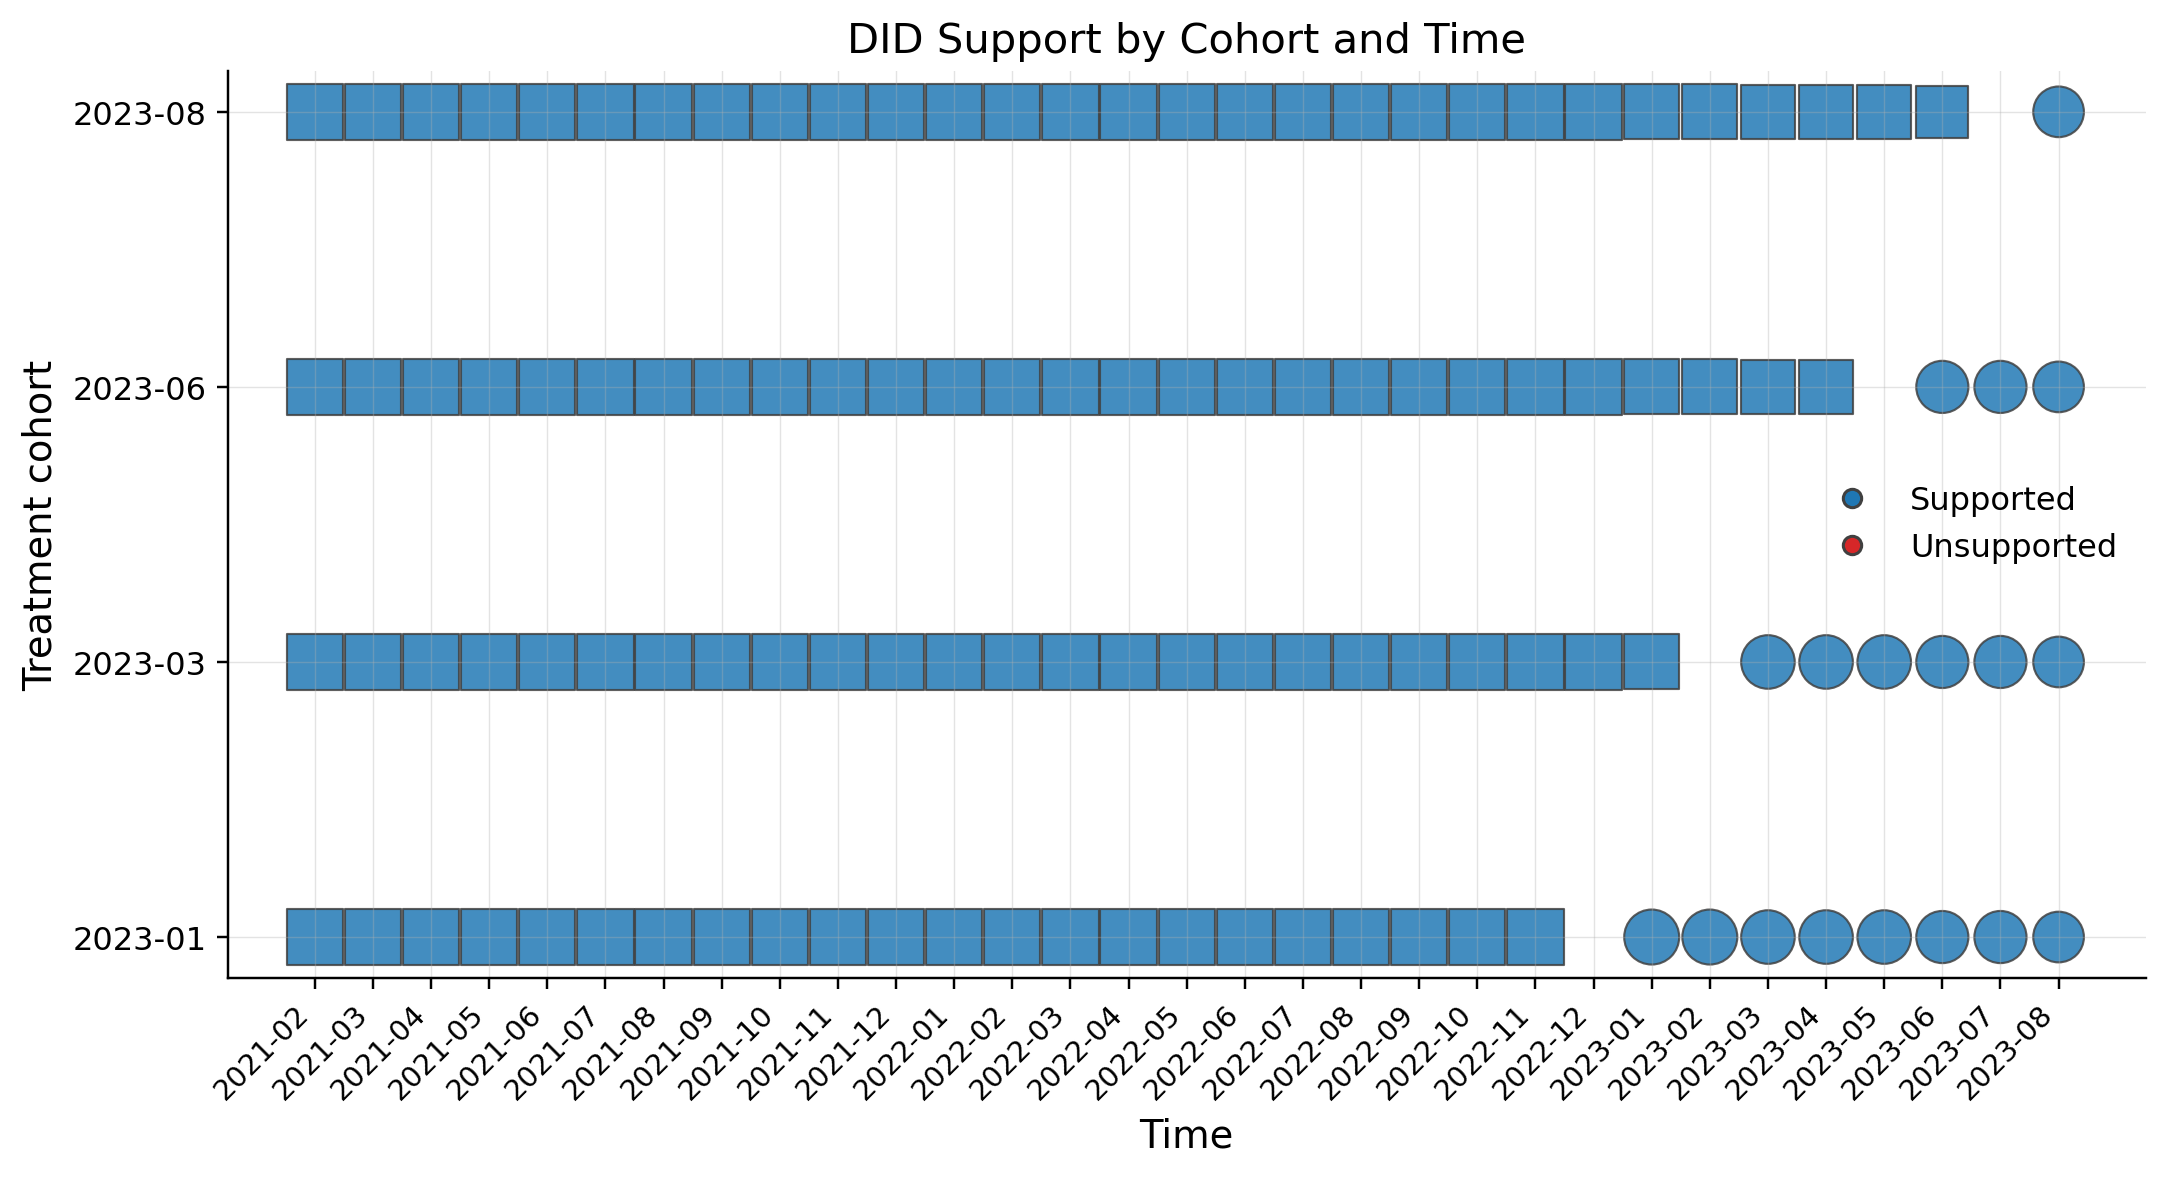

In [7]:
plot_did_support(panel_data, **cs_options)


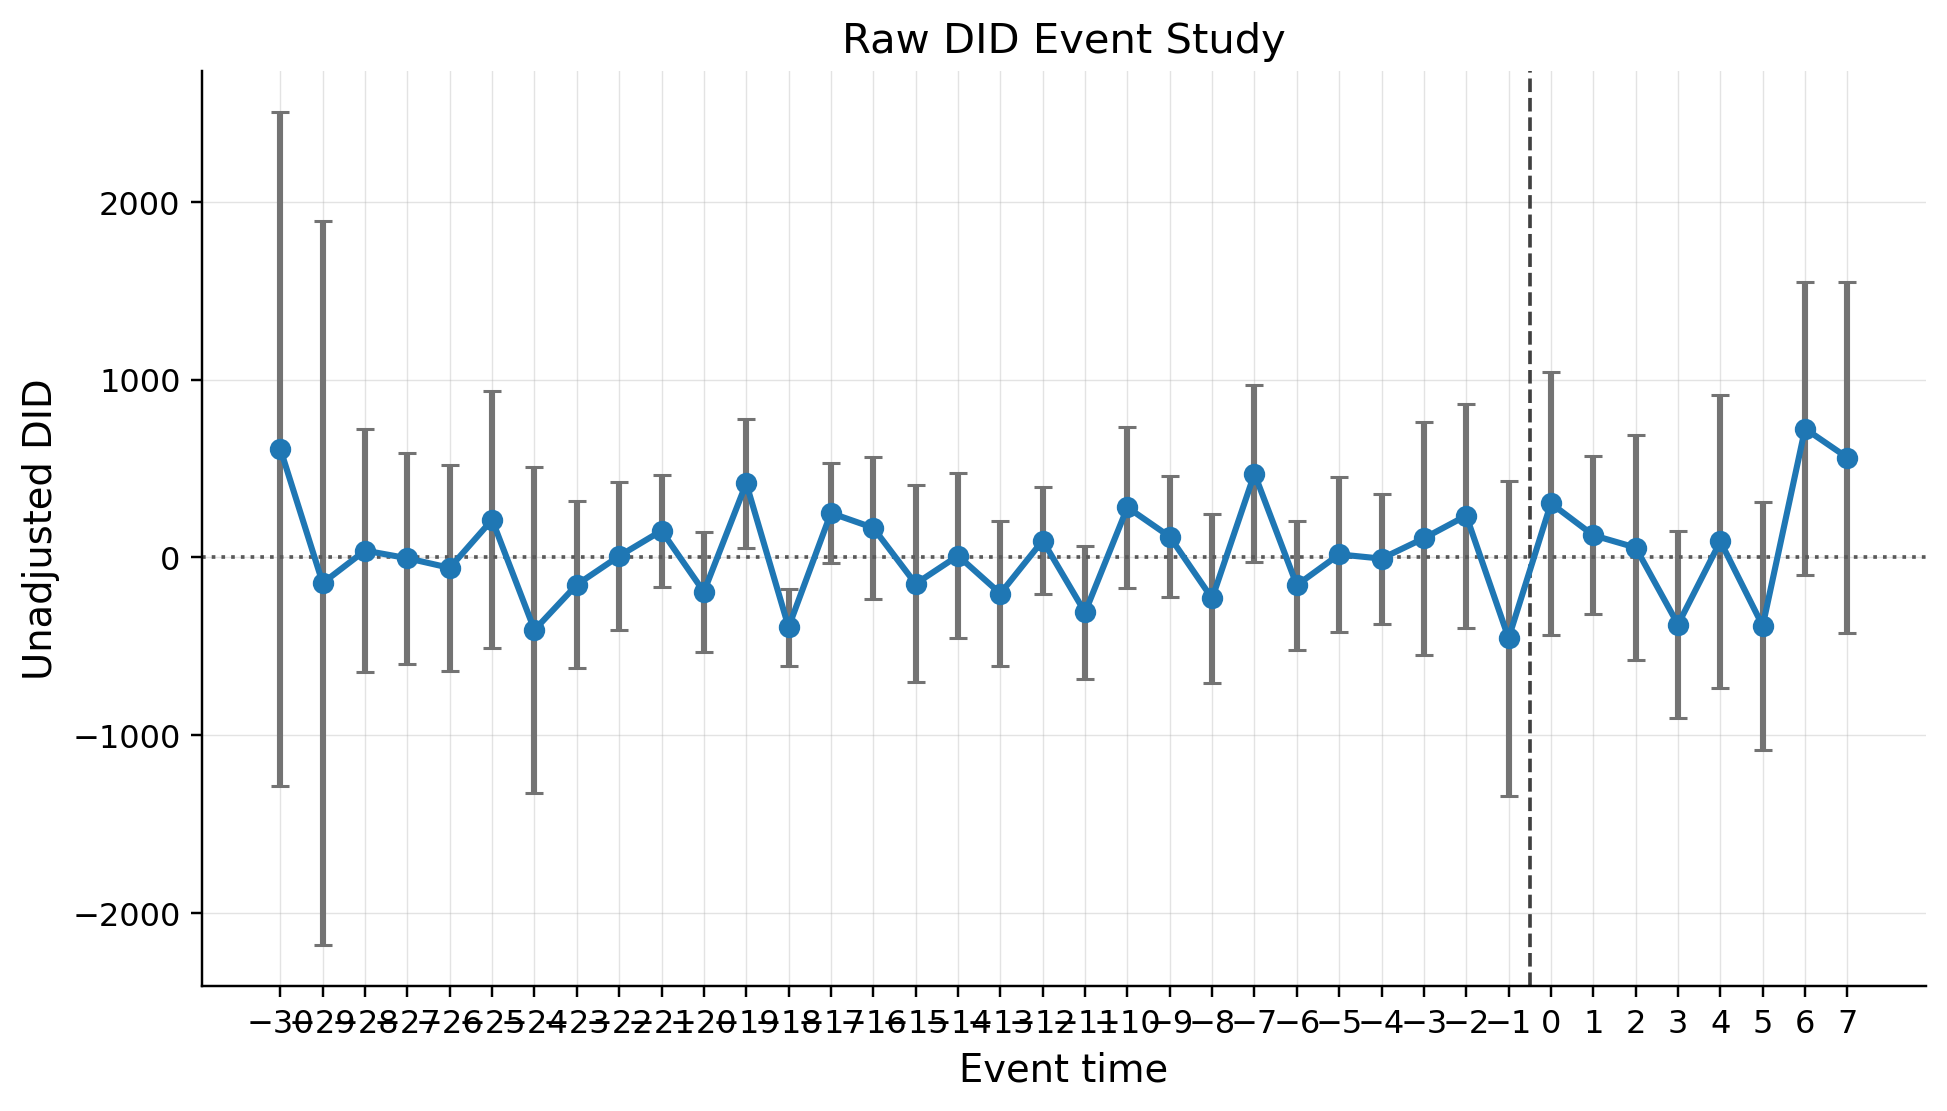

In [8]:
plot_raw_did_event_study(
    panel_data,
    control_group=cs_options["control_group"],
    anticipation=cs_options["anticipation"],
    base_period="varying",
    include_pre_periods=True,
)


## Fit the model

Use the same `cs_options` after the diagnostics look acceptable.

In [9]:
model = CallawaySantAnnaDID(
    alpha=0.05,
    min_treated_per_cell=4,
    min_control_per_cell=10,
    min_control_ess=5.0,
    max_propensity_clip_share=0.10,
    max_condition_number=1e12,
    **cs_options,
).fit(panel_data)
estimate = model.estimate()


In [10]:
estimate.summary()


,value
field,
estimand,ATT
model,CallawaySantAnnaStaggeredDID
estimator,dr
control_group,not_yet_or_never
anticipation,0
base_period,universal
include_pre_periods,True
value,"-29.0576 (ci_abs: -567.9037, 509.7884)"
std_error,274.9265


## Post-inference diagnostics

Run these after `model.fit(panel_data).estimate()`. They inspect the fitted Callaway-SantAnna inference artifacts and produce a direct reliability statement in the `overall_inference_reliability` row. The thresholds below are set for this small synthetic example; tighten them for production review.


In [11]:
from causalis.scenarios.did import (
    did_cluster_influence_table,
    did_influence_table,
    did_post_inference_cell_table,
    plot_did_influence_concentration,
    plot_did_post_inference_event_study,
    run_did_post_inference_diagnostics,
)

post_inference_report = run_did_post_inference_diagnostics(
    panel_data,
    estimate,
    min_control_ess=5.0,
    max_abs_weighted_smd=1.0,
    max_top_cluster_influence_share=0.60,
    max_abs_pretrend_t_stat=25.0,
    max_simple_cell_weight_share=0.10,
)
post_inference_report


,test,flag,value,threshold,message
0,overall_inference_reliability,GREEN,green,all checks GREEN for robust reliance,I can rely on the results: post-inference diag...
1,data_estimate_alignment,GREEN,aligned,no mismatches,PanelDataDID metadata matches the fitted estim...
2,diagnostic_payload_available,GREEN,available,"unit_level, overlap, influence_scores available",Diagnostic payload required for post-inference...
3,fitted_post_cell_support,GREEN,"{'fitted_post_cells': 18, 'skipped_post_cell_s...",skipped share <= 0.2,Fitted post-treatment cell support is within t...
4,cell_warning_flags,GREEN,{'green': 120},"0 red cells, 0 yellow cells",No fitted cells have model diagnostic warnings.
5,min_control_weight_ess,GREEN,33.849867,>= 5,Comparison weight effective sample sizes are w...
6,max_propensity_clip_share,GREEN,0.0,<= 0.05,Propensity clipping is within tolerance.
7,weighted_covariate_balance,GREEN,0.349443,max |weighted SMD| <= 1,Weighted covariate balance is within tolerance.
8,unit_influence_concentration,GREEN,"{'top_unit_share': 0.14722357015468135, 'influ...",top unit share <= 0.2; influence ESS >= 10,Unit-level influence concentration is within t...
9,cluster_influence_concentration,GREEN,"{'n_clusters': 5, 'top_cluster_share': 0.5}",clusters >= 2; top cluster share <= 0.6,Cluster influence concentration is within tole...


In [12]:
post_inference_report.loc[
    post_inference_report["test"] == "overall_inference_reliability",
    ["flag", "message"],
]


,flag,message
0,GREEN,I can rely on the results: post-inference diag...


In [13]:
cell_inference = did_post_inference_cell_table(estimate)
cell_columns = [
    col
    for col in [
        "cell_id",
        "cohort",
        "time",
        "event_time",
        "is_post_treatment",
        "att",
        "se",
        "t_stat",
        "diagnostic_status",
        "diagnostic_flags",
        "control_weight_ess",
        "propensity_clip_share",
    ]
    if col in cell_inference.columns
]

cell_inference[cell_columns].head(12)


,cell_id,cohort,time,event_time,is_post_treatment,att,se,t_stat,diagnostic_status,diagnostic_flags,control_weight_ess,propensity_clip_share
0,0,2023-01,2021-02,-23,False,-314.113235,295.157749,-1.064222,green,,54.997981,0.0
1,1,2023-01,2021-03,-22,False,-18.492365,177.720767,-0.104053,green,,54.997981,0.0
2,2,2023-01,2021-04,-21,False,-570.654340,171.655151,-3.324423,green,,54.997981,0.0
3,3,2023-01,2021-05,-20,False,-128.625147,132.517841,-0.970625,green,,54.997981,0.0
4,4,2023-01,2021-06,-19,False,542.506507,124.342205,4.363012,green,,54.997981,0.0
5,5,2023-01,2021-07,-18,False,-96.303894,259.571095,-0.371012,green,,54.997981,0.0
6,6,2023-01,2021-08,-17,False,413.299911,94.706537,4.364006,green,,54.997981,0.0
7,7,2023-01,2021-09,-16,False,379.818900,81.681147,4.650019,green,,54.997981,0.0
8,8,2023-01,2021-10,-15,False,-232.400743,131.276347,-1.770317,green,,54.997981,0.0
9,9,2023-01,2021-11,-14,False,-182.560217,169.134466,-1.079379,green,,54.997981,0.0


In [14]:
unit_influence = did_influence_table(panel_data, estimate, top_n=10)
unit_influence


,unit_id,region,rank,influence_score,abs_influence_score,abs_influence_share
0,treated_market_10,central,1,14091.211398,14091.211398,0.147224
1,treated_market_20,north,2,-5661.748264,5661.748264,0.059153
2,treated_market_07,south,3,5432.420165,5432.420165,0.056757
3,treated_market_16,north,4,-5108.071455,5108.071455,0.053369
4,treated_market_08,north,5,-4970.143570,4970.143570,0.051928
5,treated_market_04,east,6,3714.366247,3714.366247,0.038807
6,treated_market_09,east,7,-3634.032760,3634.032760,0.037968
7,treated_market_13,central,8,-3356.534904,3356.534904,0.035069
8,treated_market_06,east,9,3210.242476,3210.242476,0.033540
9,treated_market_01,west,10,-3100.333499,3100.333499,0.032392


In [15]:
cluster_influence = did_cluster_influence_table(panel_data, estimate)
cluster_influence


,region,rank,influence_score,abs_influence_score,abs_influence_share
0,north,1,-16544.423090,16544.423090,0.500000
1,south,2,7704.799238,7704.799238,0.232852
2,central,3,7226.656493,7226.656493,0.218402
3,east,4,1245.687778,1245.687778,0.037647
4,west,5,367.279581,367.279581,0.011100


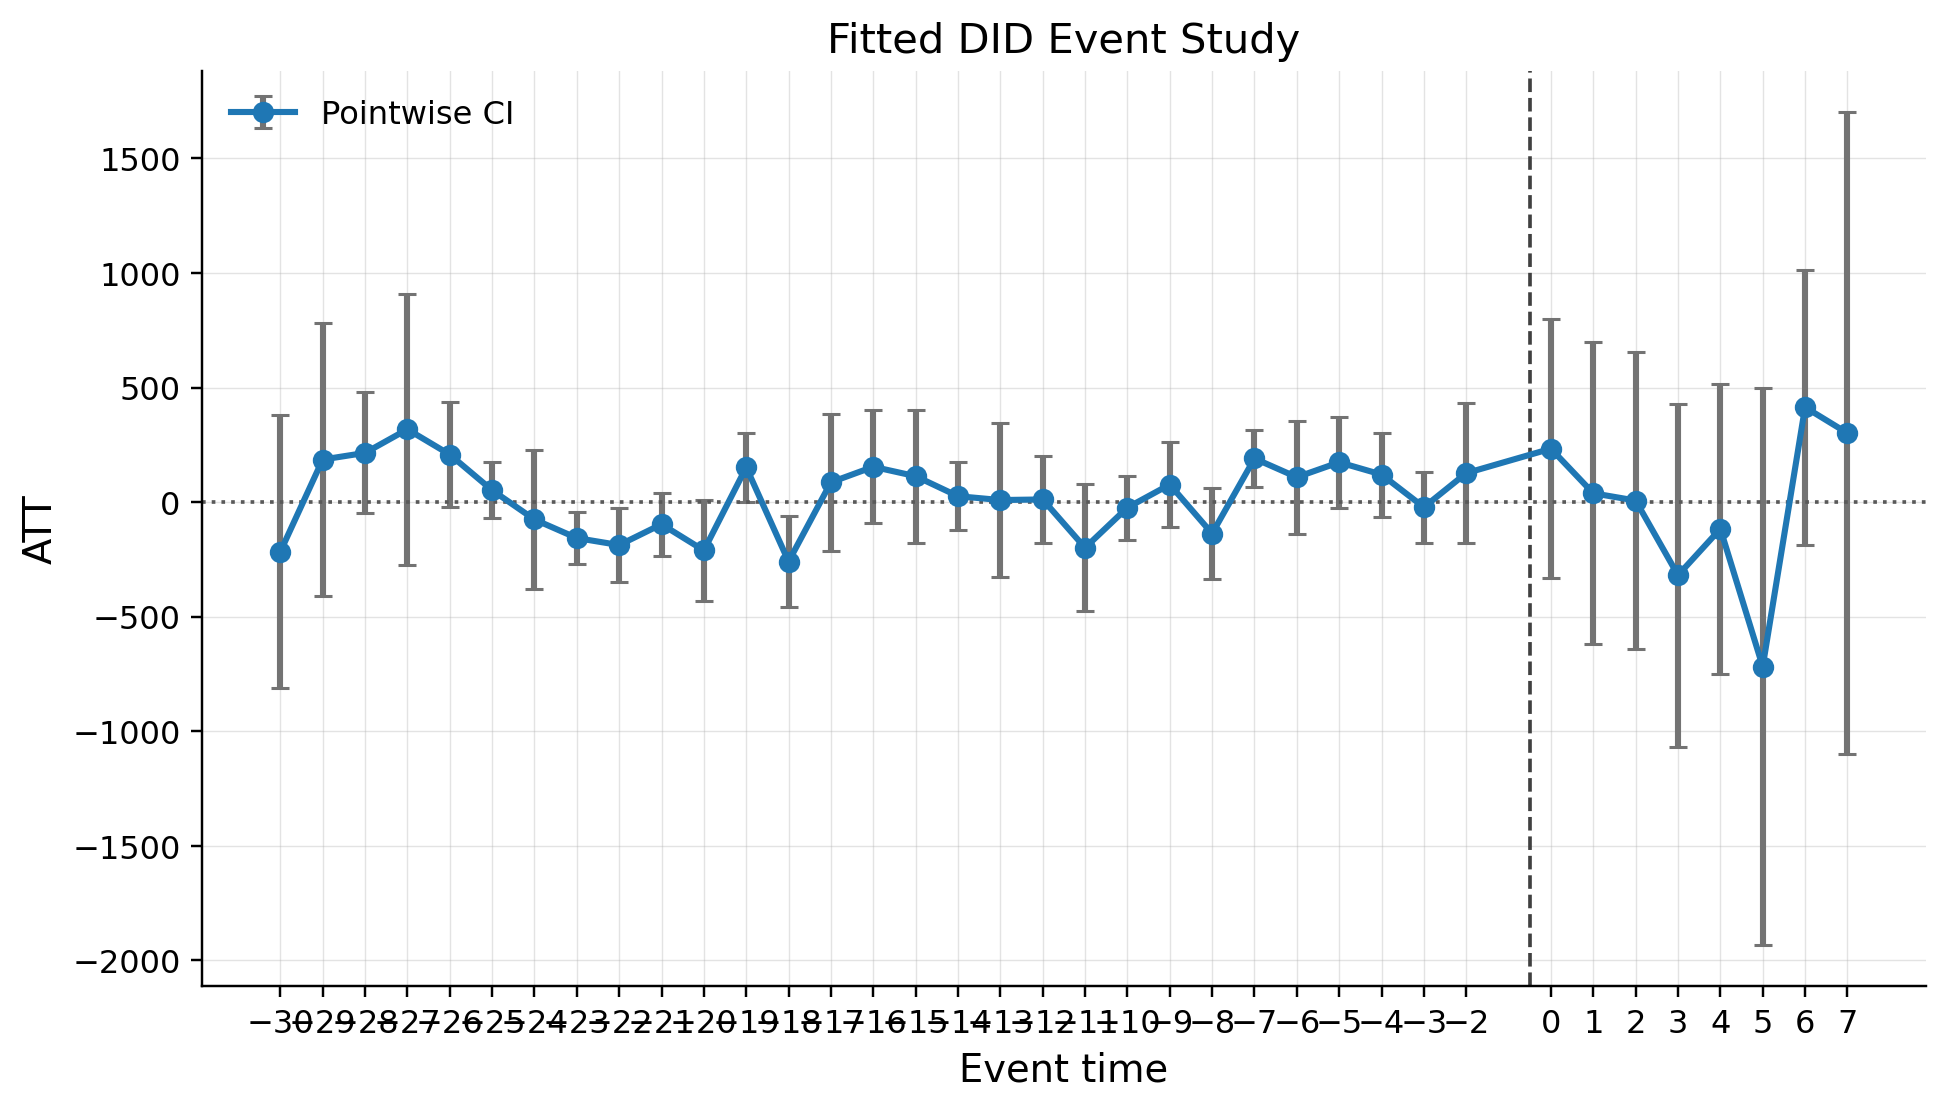

In [16]:
plot_did_post_inference_event_study(estimate)


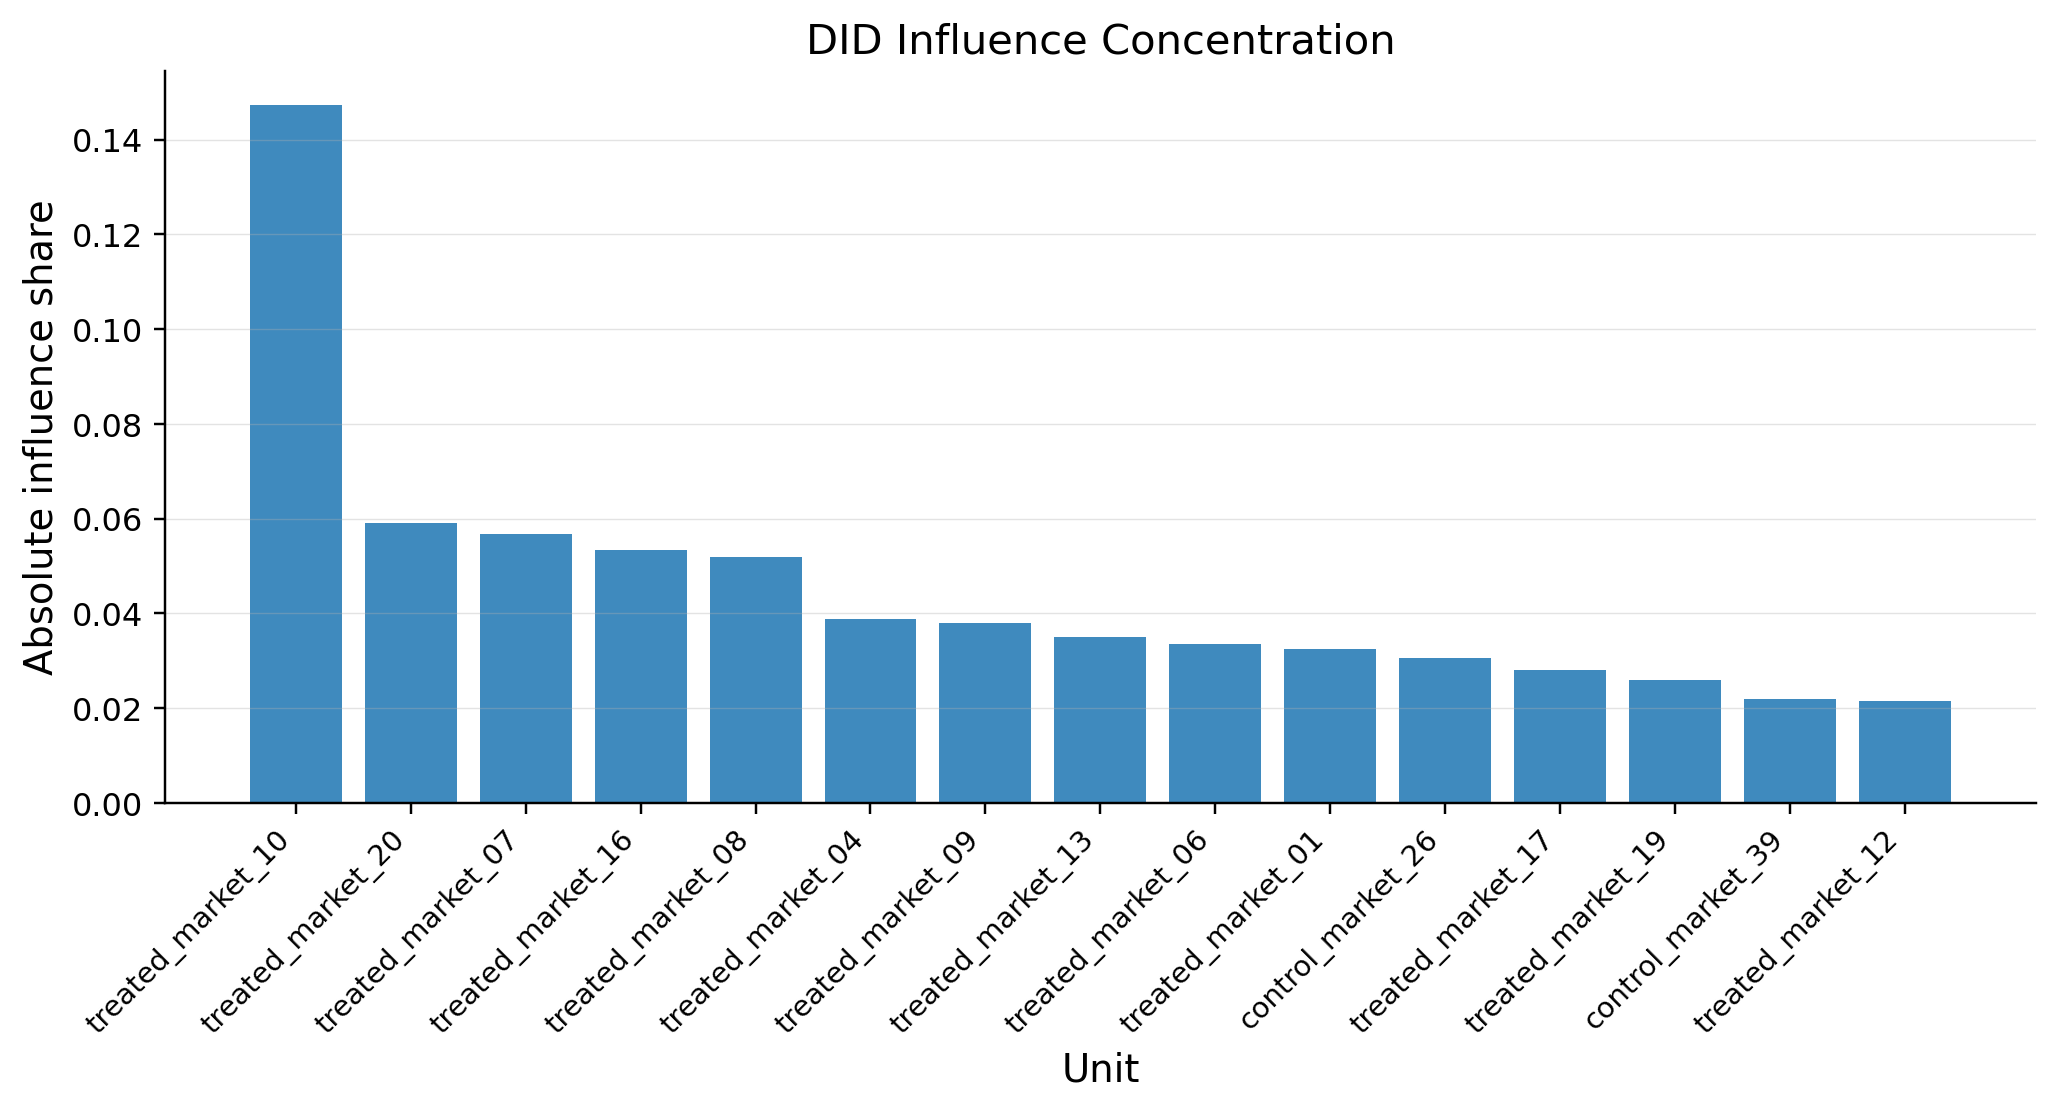

In [17]:
plot_did_influence_concentration(panel_data, estimate, top_n=15)
